100000 comments verwerkt...
300000 comments verwerkt...
600000 comments verwerkt...
[('trump', 50463), ('will', 30358), ('think', 23695), ('biden', 21653), ('even', 20354), ('now', 17887), ('vote', 17350), ('know', 16620), ('right', 16162), ('going', 15976), ('time', 15729), ('left', 14002), ('see', 13648), ('kamala', 13387), ('good', 12970), ('way', 12580), ('say', 12521), ('don', 12287), ('make', 12050), ('years', 12034), ('harris', 11844), ('election', 11697), ('said', 11481), ('much', 11250), ('democrats', 10980), ('never', 10646), ('well', 10634), ('president', 10140), ('need', 10041), ('actually', 9760)]


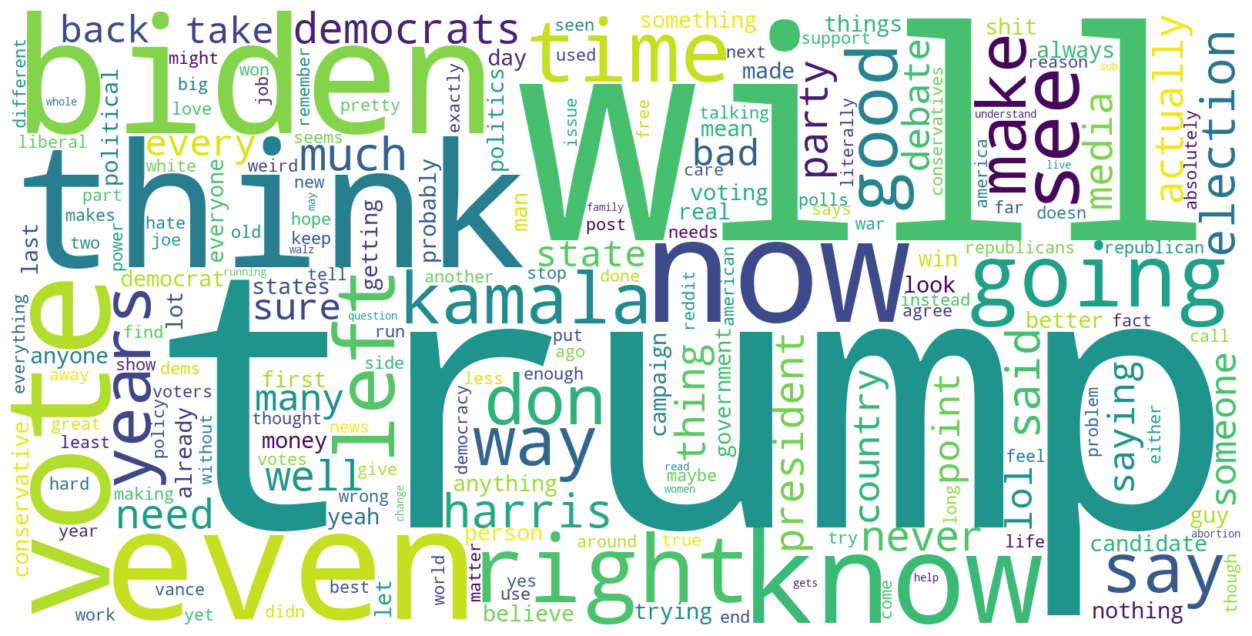

In [1]:
import json
import re
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# pad naar je bestand
file_path = "./data/r_conservative_comments.jsonl"

# extra stopwoorden
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "people", "article", "about", "want", "dont",
    "doesnt", "didnt", "theyre", "thats", "youre", "im", "aint",
    "get", "got", "one", "like", "would", "could", "really", "still"
])

word_counts = Counter()

with open(file_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, start=1):
        try:
            comment = json.loads(line)
        except json.JSONDecodeError:
            continue  # sla kapotte regels over

        body = comment.get("body", "")
        if not isinstance(body, str):
            continue

        # verwijder deleted/removed comments
        if body.lower() in ["[deleted]", "[removed]"]:
            continue

        # lowercase
        body = body.lower()

        # links verwijderen
        body = re.sub(r"http\S+|www\S+", "", body)

        # enkel woorden behouden (apostrof mag blijven)
        words = re.findall(r"\b[a-zA-Z']+\b", body)

        # filter stopwoorden en heel korte woorden
        filtered_words = [
            w for w in words
            if w not in custom_stopwords and len(w) > 2
        ]

        word_counts.update(filtered_words)

        # optioneel: progress printen elke 100000 regels
        if i % 100000 == 0:
            print(f"{i} comments verwerkt...")

# toon topwoorden
print(word_counts.most_common(30))

# maak wordcloud op basis van frequenties
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    collocations=False
).generate_from_frequencies(word_counts)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# opslaan
wordcloud.to_file("reddit_wordcloud.png")

In [3]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\seppe\AppData\Roaming\nltk_data...


True

In [6]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

sentiment = sia.polarity_scores(body)
compound = sentiment["compound"]  # belangrijkste score (-1 tot 1)

In [ ]:
import json
import re
from collections import Counter, defaultdict
from nltk.sentiment import SentimentIntensityAnalyzer

file_path = "./data/r_conservative_comments.jsonl"

sia = SentimentIntensityAnalyzer()

daily_data = defaultdict(list)

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        try:
            comment = json.loads(line)
        except:
            continue

        body = comment.get("body", "")
        created_utc = comment.get("created_utc")

        if not isinstance(body, str):
            continue

        if body.lower() in ["[deleted]", "[removed]"]:
            continue

        # date (dag niveau)
        day = int(created_utc // 86400)  # unix → dag

        # clean text
        body_clean = body.lower()
        body_clean = re.sub(r"http\S+|www\S+", "", body_clean)

        # sentiment
        sentiment = sia.polarity_scores(body_clean)
        compound = sentiment["compound"]

        # candidate mentions
        trump = "trump" in body_clean
        harris = "harris" in body_clean or "kamala" in body_clean

        # save alles
        daily_data[day].append({
            "sentiment": compound,
            "trump": trump,
            "harris": harris,
            "length": len(body_clean)
        })